In [4]:
import os
print(os.path.getsize('QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272_LR.parquet') / (1024**3), "GB")

0.8974492289125919 GB


In [5]:
!rocm-smi



============================================ ROCm System Management Interface ============================================
====================================================== Concise Info ======================================================
Device  Node  IDs              Temp        Power     Partitions          SCLK    MCLK    Fan  Perf  PwrCap  VRAM%  GPU%  
              (DID,     GUID)  (Junction)  (Socket)  (Mem, Compute, ID)                                                  
0       1     0x74b5,   21947  54.0°C      172.0W    NPS1, SPX, 0        142Mhz  900Mhz  0%   auto  750.0W  0%     0%    
================================================== End of ROCm SMI Log ===================================================


In [6]:
import pyarrow.parquet as pq
pf = pq.ParquetFile("QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272_LR.parquet")

print("Number of rows:", pf.metadata.num_rows)
print("\nSchema:\n")
print(pf.schema)

Number of rows: 36272

Schema:

required group field_id=-1 schema {
  optional group field_id=-1 X_jets_LR (List) {
    repeated group field_id=-1 list {
      optional group field_id=-1 element (List) {
        repeated group field_id=-1 list {
          optional group field_id=-1 element (List) {
            repeated group field_id=-1 list {
              optional double field_id=-1 element;
            }
          }
        }
      }
    }
  }
  optional group field_id=-1 X_jets (List) {
    repeated group field_id=-1 list {
      optional group field_id=-1 element (List) {
        repeated group field_id=-1 list {
          optional group field_id=-1 element (List) {
            repeated group field_id=-1 list {
              optional double field_id=-1 element;
            }
          }
        }
      }
    }
  }
  optional double field_id=-1 pt;
  optional double field_id=-1 m0;
  optional double field_id=-1 y;
}



In [10]:
import pandas as pd

df = pd.read_parquet("QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272_LR.parquet")

print(df.columns)
print(df.head())

Index(['X_jets_LR', 'X_jets', 'pt', 'm0', 'y'], dtype='object')
                                           X_jets_LR  \
0  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...   
1  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...   
2  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...   
3  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...   
4  [[[0.0, 0.0, 0.0, 0.0, 0.08212081342935562, 0....   

                                              X_jets          pt         m0  \
0  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...  112.411095  21.098248   
1  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...   95.220406  14.030600   
2  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...   97.007317  17.728968   
3  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...   82.490311  14.702741   
4  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.328483...  102.539238  19.456257   

     y  
0  0.0  
1  1.0  
2  1.0  
3  0.0  
4  0.0  


In [92]:
import torch
import pandas as pd

# Load parquet
df = pd.read_parquet("QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272_LR.parquet")

# Global min/max
LR_MIN = -4.146373748779297
LR_MAX = 2123.319091796875
HR_MIN = -10.544231414794922
HR_MAX = 8477.8427734375

def normalize(x, min_val, max_val):
    
    # Convert object array to Python list first
    x_list = x.tolist() if isinstance(x, (np.ndarray, np.generic)) else x
    x_tensor = torch.tensor(x_list, dtype=torch.float32)
    x_norm = (x_tensor - min_val) / (max_val - min_val)  # scale to [0,1]
    x_norm = x_norm * 2 - 1                               # scale to [-1,1]
    return x_norm

# Normalize each row safely
lr_normalized = [normalize(x, LR_MIN, LR_MAX) for x in df["X_jets_LR"]]
hr_normalized = [normalize(x, HR_MIN, HR_MAX) for x in df["X_jets"]]

# Convert labels
y = torch.tensor(df["y"].tolist(), dtype=torch.float32)

# Check first sample
print("LR shape:", lr_normalized[0].shape)
print("HR shape:", hr_normalized[0].shape)
print("LR min/max:", lr_normalized[0].min().item(), lr_normalized[0].max().item())
print("HR min/max:", hr_normalized[0].min().item(), hr_normalized[0].max().item())

LR shape: torch.Size([3, 64, 64])
HR shape: torch.Size([3, 125, 125])
LR min/max: -0.9961627125740051 -0.9883572459220886
HR min/max: -0.9975666403770447 -0.9945300221443176


In [93]:
from torch.utils.data import Dataset, DataLoader


class JetDataset(Dataset):
    def __init__(self, lr_list, hr_list, y_tensor):
        self.lr = lr_list
        self.hr = hr_list
        self.y = y_tensor

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.lr[idx], self.hr[idx], self.y[idx]


# Create dataset and DataLoader

dataset = JetDataset(lr_normalized, hr_normalized, y)
batch_size = 16
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print(f"Dataset ready with {len(dataset)} samples")

Dataset ready with 36272 samples


In [124]:
#  check first batch
lr_batch, hr_batch, _ = next(iter(dataloader))

print("LR min:", lr_batch.min().item())
print("LR max:", lr_batch.max().item())

LR min: -0.9963263273239136
LR max: -0.9744505882263184


In [125]:
print("HR min:", hr_batch.min().item())
print("HR max:", hr_batch.max().item())

HR min: -0.9977404475212097
HR max: -0.9758093357086182


In [127]:
print("LR size:", lr_batch.shape)
print("HR size:", hr_batch.shape)
print("SR size:", sr_sample.shape)

LR size: torch.Size([16, 3, 64, 64])
HR size: torch.Size([16, 3, 125, 125])
SR size: torch.Size([16, 3, 125, 125])


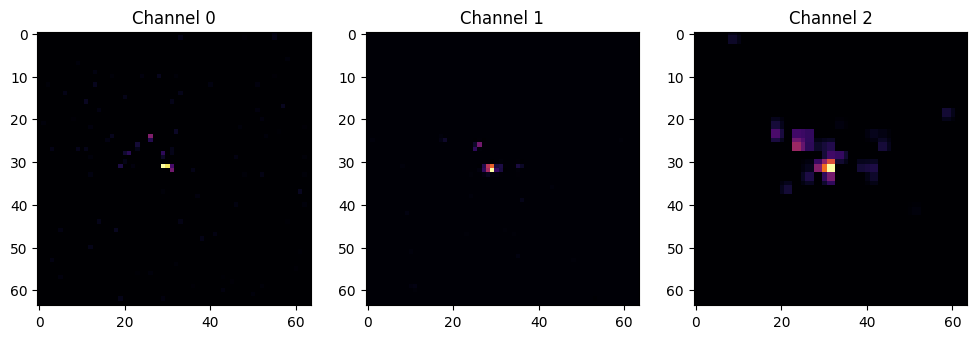

In [19]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Channel 0")
plt.imshow(lr[0][0].cpu(), cmap="inferno")

plt.subplot(1,3,2)
plt.title("Channel 1")
plt.imshow(lr[0][1].cpu(), cmap="inferno")

plt.subplot(1,3,3)
plt.title("Channel 2")
plt.imshow(lr[0][2].cpu(), cmap="inferno")

plt.show()

In [142]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Generator(nn.Module):
    def __init__(self, in_channels=3, num_res_blocks=4):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 64, 9, padding=4)
        self.relu = nn.PReLU()

        # Residual blocks
        self.resblocks = nn.Sequential(
            *[self._res_block(64) for _ in range(num_res_blocks)]
        )

        self.conv2 = nn.Conv2d(64, 64, 3, padding=1)

        # Upsampling blocks
        self.up1 = nn.Sequential(
            nn.Conv2d(64, 256, 3, 1, 1),
            nn.PixelShuffle(2),
            nn.PReLU()
        )
        self.up2 = nn.Sequential(
            nn.Conv2d(64, 256, 3, 1, 1),
            nn.PixelShuffle(2),
            nn.PReLU()
        )

        self.final = nn.Conv2d(64, in_channels, 9, padding=4)

    def _res_block(self, channels):
        return nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.PReLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels)
        )

    def forward(self, x):
        out1 = self.relu(self.conv1(x))
        res = self.resblocks(out1)
        out = self.conv2(res) + out1  # skip
        out = self.up1(out)
        out = self.up2(out)
        out = self.final(out)
        return out

In [143]:
class Discriminator(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels, 64, 3, stride=1, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 1, 3, stride=1, padding=1),
            nn.Sigmoid()  # output [0,1]
        )

    def forward(self, x):
        return self.model(x)

In [144]:
# Normalize LR and HR to [-1,1]
def normalize(x):
    x = torch.tensor(x.tolist(), dtype=torch.float32) if hasattr(x, 'tolist') else torch.tensor(x, dtype=torch.float32)
    return x*2 - 1 

lr_list = [normalize(x) for x in df["X_jets_LR"]]
hr_list = [normalize(x) for x in df["X_jets"]]
y_tensor = torch.tensor(df["y"].tolist(), dtype=torch.float32)

from torch.utils.data import Dataset, DataLoader

class JetDataset(Dataset):
    def __init__(self, lr_list, hr_list, y_tensor):
        self.lr = lr_list
        self.hr = hr_list
        self.y = y_tensor

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.lr[idx], self.hr[idx], self.y[idx]

dataset = JetDataset(lr_list, hr_list, y_tensor)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

Epoch [1/200] Loss D: 0.117327 Loss G: 0.054911
Epoch [2/200] Loss D: 0.043863 Loss G: 0.272916
Epoch [3/200] Loss D: 0.008180 Loss G: 0.046207
Epoch [4/200] Loss D: 0.002410 Loss G: 0.054161
Epoch [5/200] Loss D: 0.000832 Loss G: 0.047711
Epoch [6/200] Loss D: 0.000317 Loss G: 0.064837
Epoch [7/200] Loss D: 0.000139 Loss G: 0.051244
Epoch [8/200] Loss D: 0.000070 Loss G: 0.052676
Epoch [9/200] Loss D: 0.000022 Loss G: 0.056690
Epoch [10/200] Loss D: 0.000012 Loss G: 0.068148


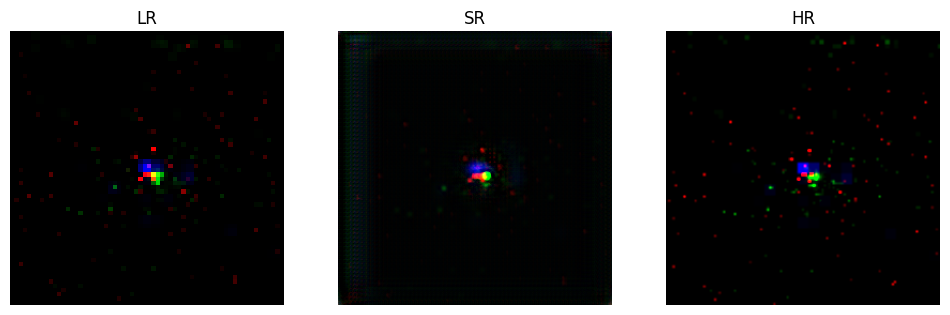

Epoch [11/200] Loss D: 0.000006 Loss G: 0.083682
Epoch [12/200] Loss D: 0.000004 Loss G: 0.042424
Epoch [13/200] Loss D: 0.000001 Loss G: 0.066418
Epoch [14/200] Loss D: 0.000000 Loss G: 0.053331
Epoch [15/200] Loss D: 0.000008 Loss G: 0.056759
Epoch [16/200] Loss D: 0.000001 Loss G: 0.050981
Epoch [17/200] Loss D: 0.000001 Loss G: 0.048782
Epoch [18/200] Loss D: 0.000001 Loss G: 0.079868
Epoch [19/200] Loss D: 0.000000 Loss G: 0.062845
Epoch [20/200] Loss D: 0.000001 Loss G: 0.044418


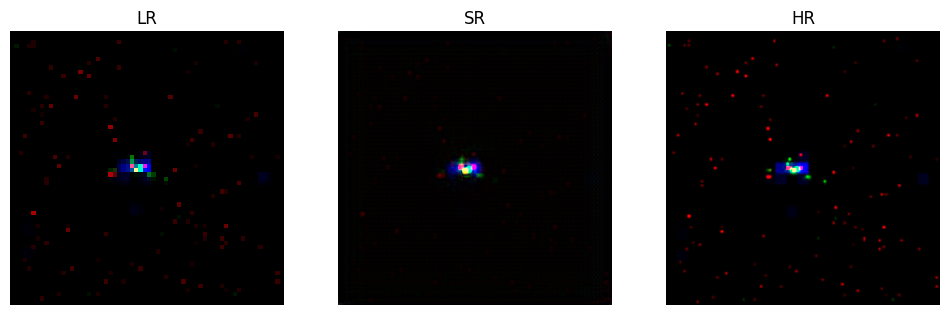

Epoch [21/200] Loss D: 0.000000 Loss G: 0.049263
Epoch [22/200] Loss D: 0.000000 Loss G: 0.052627
Epoch [23/200] Loss D: 0.000001 Loss G: 0.044431
Epoch [24/200] Loss D: 0.000000 Loss G: 0.046578
Epoch [25/200] Loss D: 0.000000 Loss G: 0.059632
Epoch [26/200] Loss D: 0.000000 Loss G: 0.044868
Epoch [27/200] Loss D: 0.000000 Loss G: 0.052924
Epoch [28/200] Loss D: 0.000000 Loss G: 0.055463
Epoch [29/200] Loss D: 0.000000 Loss G: 0.050558
Epoch [30/200] Loss D: 0.000000 Loss G: 0.067317


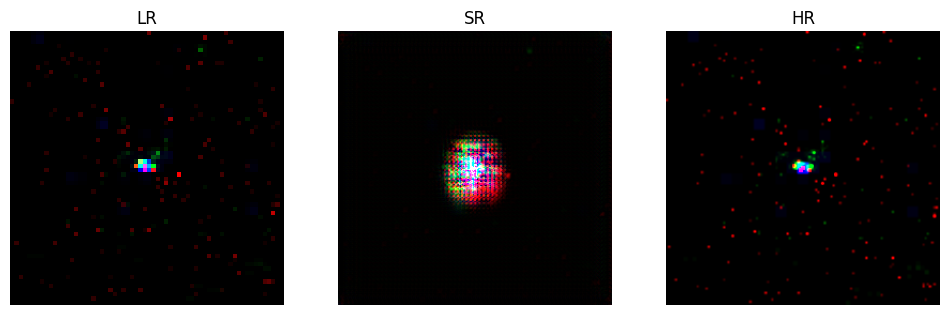

Epoch [31/200] Loss D: 0.000000 Loss G: 0.051195
Epoch [32/200] Loss D: 0.000000 Loss G: 0.058864
Epoch [33/200] Loss D: 0.000000 Loss G: 0.077406
Epoch [34/200] Loss D: 0.000000 Loss G: 0.058198
Epoch [35/200] Loss D: 0.000000 Loss G: 0.058006
Epoch [36/200] Loss D: 0.000000 Loss G: 0.069977
Epoch [37/200] Loss D: 0.000000 Loss G: 0.052446
Epoch [38/200] Loss D: 0.000000 Loss G: 0.121704
Epoch [39/200] Loss D: 0.000000 Loss G: 0.047054
Epoch [40/200] Loss D: 0.000000 Loss G: 0.051953


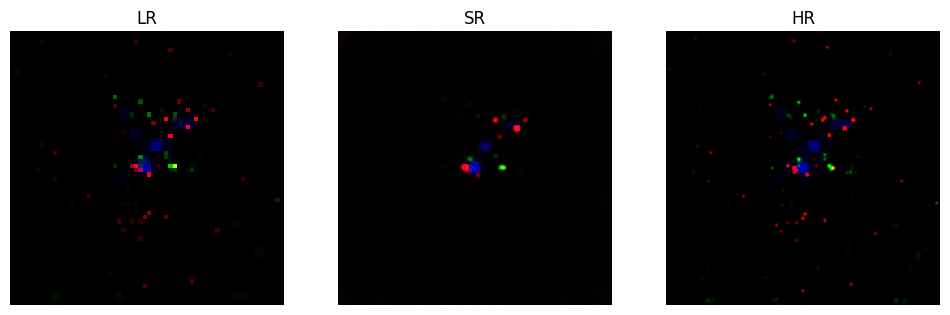

Epoch [41/200] Loss D: 0.000000 Loss G: 0.071721
Epoch [42/200] Loss D: 0.000000 Loss G: 0.061965
Epoch [43/200] Loss D: 0.000000 Loss G: 0.069778
Epoch [44/200] Loss D: 0.000000 Loss G: 0.050759
Epoch [45/200] Loss D: 0.000000 Loss G: 0.063502
Epoch [46/200] Loss D: 0.000000 Loss G: 0.104280
Epoch [47/200] Loss D: 0.000000 Loss G: 0.057576
Epoch [48/200] Loss D: 0.000000 Loss G: 0.092866
Epoch [49/200] Loss D: 0.000000 Loss G: 0.068864
Epoch [50/200] Loss D: 0.000000 Loss G: 0.056603


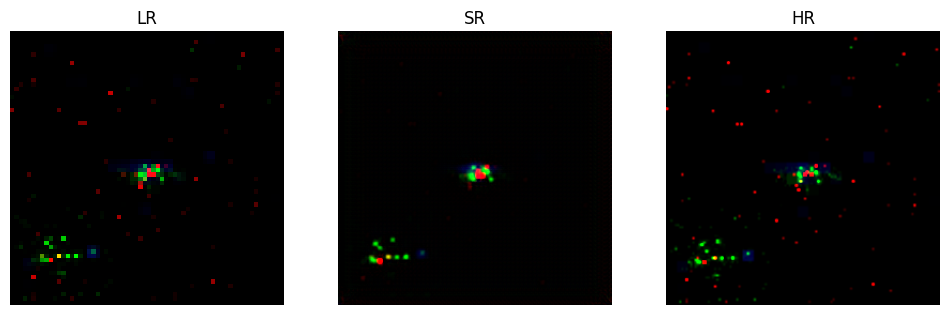

Epoch [51/200] Loss D: 0.000000 Loss G: 0.073957
Epoch [52/200] Loss D: 0.000000 Loss G: 0.058948
Epoch [53/200] Loss D: 0.000000 Loss G: 0.064243
Epoch [54/200] Loss D: 0.000000 Loss G: 0.064570
Epoch [55/200] Loss D: 0.000000 Loss G: 0.070453
Epoch [56/200] Loss D: 0.000000 Loss G: 0.075127
Epoch [57/200] Loss D: 0.000000 Loss G: 0.061476
Epoch [58/200] Loss D: 0.000000 Loss G: 0.062612
Epoch [59/200] Loss D: 0.000000 Loss G: 0.078253
Epoch [60/200] Loss D: 0.000000 Loss G: 0.065848


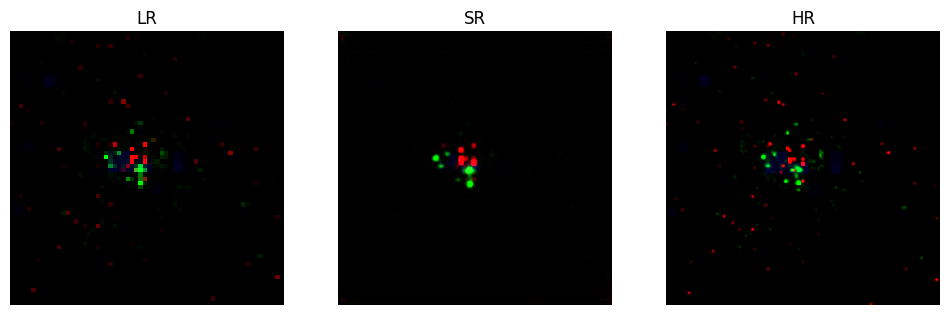

Epoch [61/200] Loss D: 0.000000 Loss G: 0.052731
Epoch [62/200] Loss D: 0.000000 Loss G: 0.049456
Epoch [63/200] Loss D: 0.000000 Loss G: 0.062454
Epoch [64/200] Loss D: 0.000000 Loss G: 0.057034
Epoch [65/200] Loss D: 0.000000 Loss G: 0.054121
Epoch [66/200] Loss D: 0.000000 Loss G: 0.059445
Epoch [67/200] Loss D: 0.000000 Loss G: 0.060625
Epoch [68/200] Loss D: 0.000000 Loss G: 0.055459
Epoch [69/200] Loss D: 0.000000 Loss G: 0.061786
Epoch [70/200] Loss D: 0.000000 Loss G: 0.061049


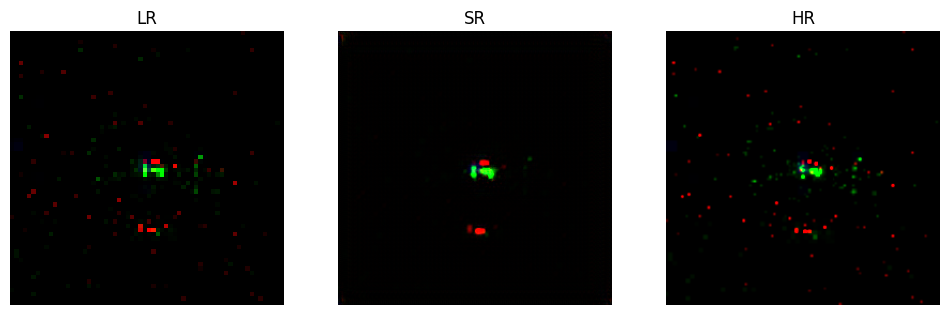

Epoch [71/200] Loss D: 0.000000 Loss G: 0.144690
Epoch [72/200] Loss D: 0.000000 Loss G: 0.063540
Epoch [73/200] Loss D: 0.000000 Loss G: 0.085912
Epoch [74/200] Loss D: 0.000000 Loss G: 0.046222
Epoch [75/200] Loss D: 0.000000 Loss G: 0.062647
Epoch [76/200] Loss D: 0.000000 Loss G: 0.054341
Epoch [77/200] Loss D: 0.000000 Loss G: 0.049771
Epoch [78/200] Loss D: 0.000000 Loss G: 0.048645
Epoch [79/200] Loss D: 0.000000 Loss G: 0.066842
Epoch [80/200] Loss D: 0.000000 Loss G: 0.071322


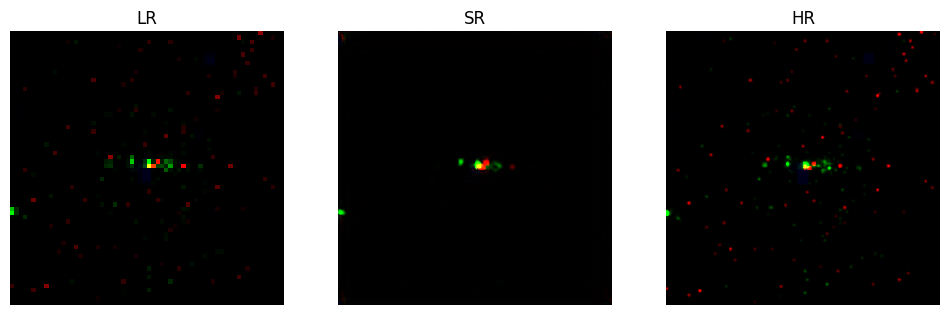

Epoch [81/200] Loss D: 0.000000 Loss G: 0.067925
Epoch [82/200] Loss D: 0.000000 Loss G: 0.062412
Epoch [83/200] Loss D: 0.000000 Loss G: 0.096061
Epoch [84/200] Loss D: 0.000000 Loss G: 0.059610
Epoch [85/200] Loss D: 0.000000 Loss G: 0.063756
Epoch [86/200] Loss D: 0.000000 Loss G: 0.064372
Epoch [87/200] Loss D: 0.000000 Loss G: 0.049755
Epoch [88/200] Loss D: 0.000000 Loss G: 0.067675
Epoch [89/200] Loss D: 0.000000 Loss G: 0.060552
Epoch [90/200] Loss D: 0.000000 Loss G: 0.065249


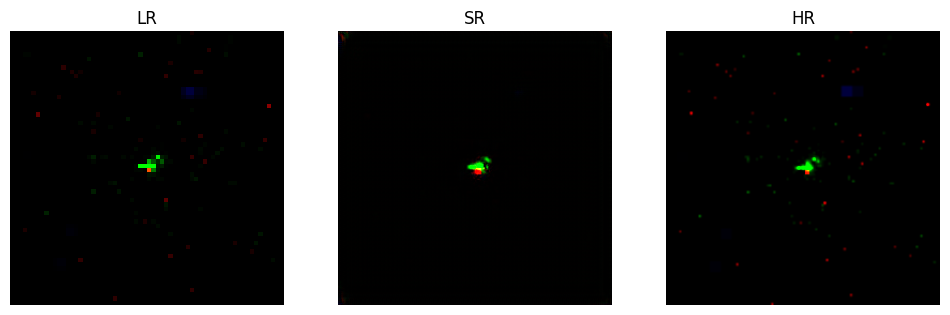

Epoch [91/200] Loss D: 0.000000 Loss G: 0.074794
Epoch [92/200] Loss D: 0.000000 Loss G: 0.059683
Epoch [93/200] Loss D: 0.000000 Loss G: 0.055258
Epoch [94/200] Loss D: 0.000000 Loss G: 0.060404
Epoch [95/200] Loss D: 0.000000 Loss G: 0.042906
Epoch [96/200] Loss D: 0.000000 Loss G: 0.068159
Epoch [97/200] Loss D: 0.000000 Loss G: 0.047765
Epoch [98/200] Loss D: 0.000000 Loss G: 0.057522
Epoch [99/200] Loss D: 0.000000 Loss G: 0.053370
Epoch [100/200] Loss D: 0.000000 Loss G: 0.070222


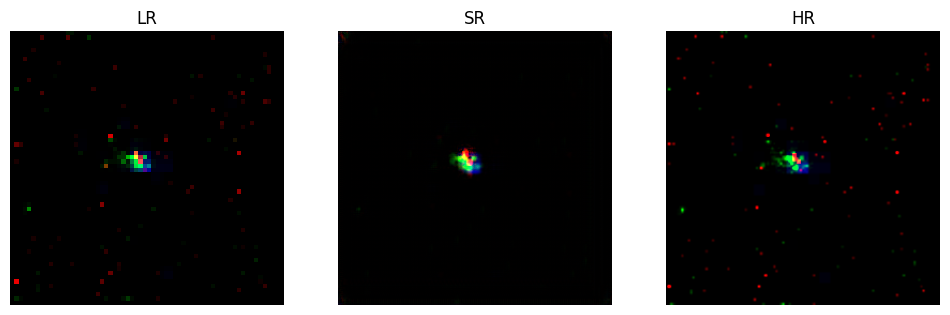

Epoch [101/200] Loss D: 0.000000 Loss G: 0.071043
Epoch [102/200] Loss D: 0.000000 Loss G: 0.052244
Epoch [103/200] Loss D: 0.000000 Loss G: 0.082180
Epoch [104/200] Loss D: 0.000000 Loss G: 0.058009
Epoch [105/200] Loss D: 0.000000 Loss G: 0.053902
Epoch [106/200] Loss D: 0.000000 Loss G: 0.048987
Epoch [107/200] Loss D: 0.000000 Loss G: 0.064083
Epoch [108/200] Loss D: 0.000000 Loss G: 0.067640
Epoch [109/200] Loss D: 0.000000 Loss G: 0.053999
Epoch [110/200] Loss D: 0.000000 Loss G: 0.065341


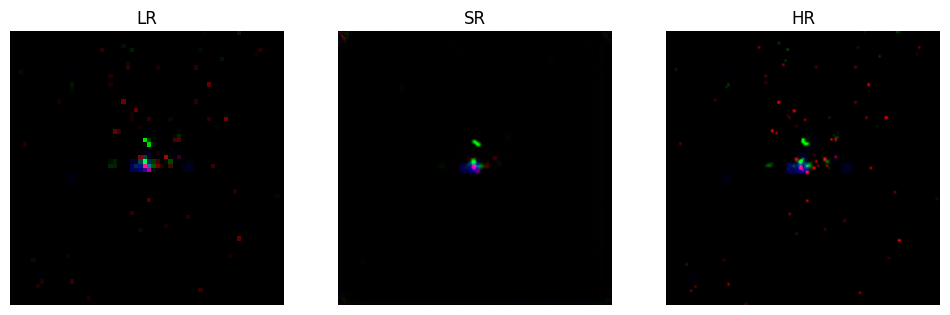

Epoch [111/200] Loss D: 0.000000 Loss G: 0.060485
Epoch [112/200] Loss D: 0.000000 Loss G: 0.077338
Epoch [113/200] Loss D: 0.000000 Loss G: 0.063150
Epoch [114/200] Loss D: 0.000000 Loss G: 0.051549
Epoch [115/200] Loss D: 0.000000 Loss G: 0.210338
Epoch [116/200] Loss D: 0.000000 Loss G: 0.072649
Epoch [117/200] Loss D: 0.000000 Loss G: 0.055596
Epoch [118/200] Loss D: 0.000000 Loss G: 0.060575
Epoch [119/200] Loss D: 0.000000 Loss G: 0.060003
Epoch [120/200] Loss D: 0.000000 Loss G: 0.065969


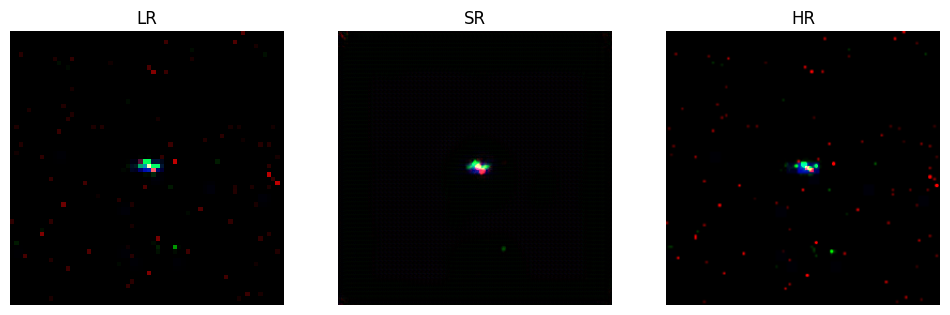

Epoch [121/200] Loss D: 0.000000 Loss G: 0.050782
Epoch [122/200] Loss D: 0.000000 Loss G: 0.048457
Epoch [123/200] Loss D: 0.000000 Loss G: 0.051374
Epoch [124/200] Loss D: 0.000000 Loss G: 0.069579
Epoch [125/200] Loss D: 0.000000 Loss G: 0.071976
Epoch [126/200] Loss D: 0.000000 Loss G: 0.052811
Epoch [127/200] Loss D: 0.000000 Loss G: 0.052044
Epoch [128/200] Loss D: 0.000000 Loss G: 0.054190
Epoch [129/200] Loss D: 0.000000 Loss G: 0.065387
Epoch [130/200] Loss D: 0.000000 Loss G: 0.066646


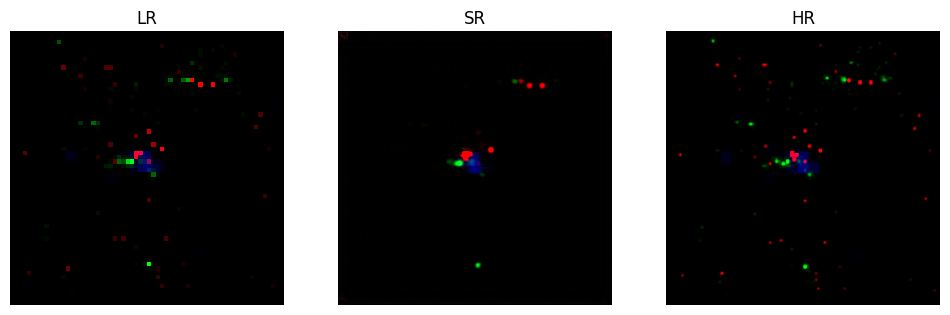

Epoch [131/200] Loss D: 0.000000 Loss G: 0.069471
Epoch [132/200] Loss D: 0.000000 Loss G: 0.052086
Epoch [133/200] Loss D: 0.000000 Loss G: 0.055657
Epoch [134/200] Loss D: 0.000000 Loss G: 0.057250
Epoch [135/200] Loss D: 0.000000 Loss G: 0.069049
Epoch [136/200] Loss D: 0.000000 Loss G: 0.078883
Epoch [137/200] Loss D: 0.000000 Loss G: 0.052885
Epoch [138/200] Loss D: 0.000000 Loss G: 0.055678
Epoch [139/200] Loss D: 0.000000 Loss G: 0.044732
Epoch [140/200] Loss D: 0.000000 Loss G: 0.062495


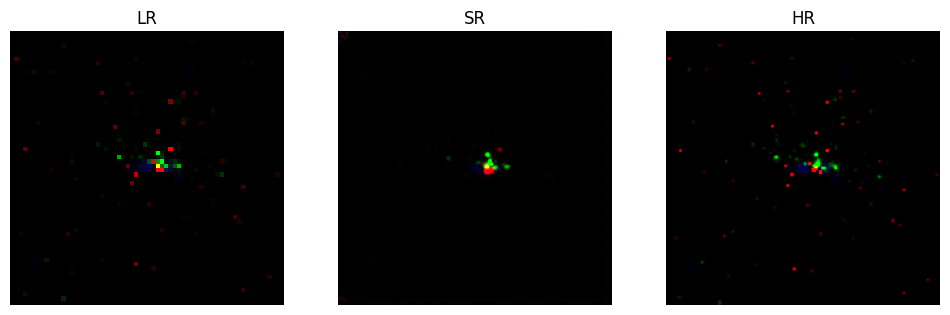

Epoch [141/200] Loss D: 0.000000 Loss G: 0.061007
Epoch [142/200] Loss D: 0.000000 Loss G: 0.055623
Epoch [143/200] Loss D: 0.000000 Loss G: 0.058856
Epoch [144/200] Loss D: 0.000000 Loss G: 0.047950
Epoch [145/200] Loss D: 0.000000 Loss G: 0.049763
Epoch [146/200] Loss D: 0.000000 Loss G: 0.051177
Epoch [147/200] Loss D: 0.000000 Loss G: 0.049900
Epoch [148/200] Loss D: 0.000000 Loss G: 0.063322
Epoch [149/200] Loss D: 0.000000 Loss G: 0.063616
Epoch [150/200] Loss D: 0.000000 Loss G: 0.066643


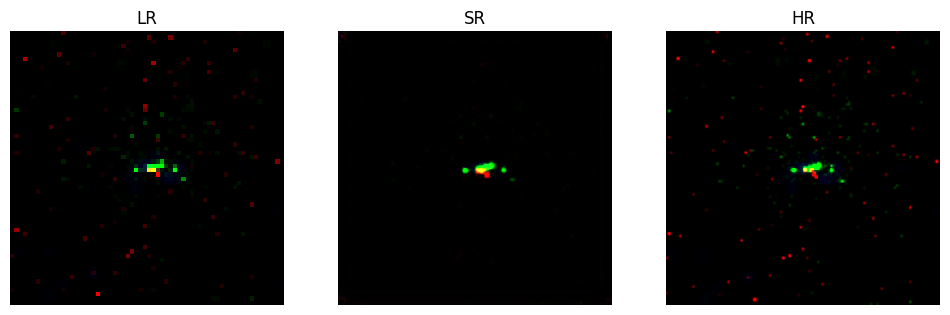

Epoch [151/200] Loss D: 0.000000 Loss G: 0.059134
Epoch [152/200] Loss D: 0.000000 Loss G: 0.060262
Epoch [153/200] Loss D: 0.000000 Loss G: 0.059967
Epoch [154/200] Loss D: 0.000000 Loss G: 0.053754
Epoch [155/200] Loss D: 0.000000 Loss G: 0.060136
Epoch [156/200] Loss D: 0.000000 Loss G: 0.067331
Epoch [157/200] Loss D: 0.000000 Loss G: 0.054862
Epoch [158/200] Loss D: 0.000000 Loss G: 0.059921
Epoch [159/200] Loss D: 0.000000 Loss G: 0.053041
Epoch [160/200] Loss D: 0.000000 Loss G: 0.060263


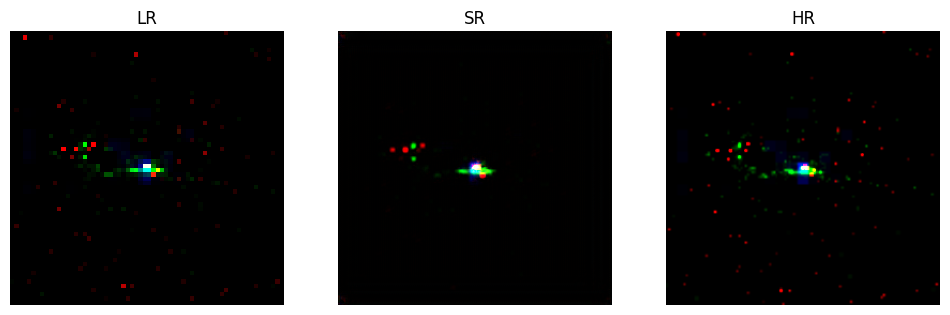

Epoch [161/200] Loss D: 0.000000 Loss G: 0.068508
Epoch [162/200] Loss D: 0.000000 Loss G: 0.057409
Epoch [163/200] Loss D: 0.000000 Loss G: 0.065295
Epoch [164/200] Loss D: 0.000000 Loss G: 0.070249
Epoch [165/200] Loss D: 0.000000 Loss G: 0.062089
Epoch [166/200] Loss D: 0.000000 Loss G: 0.048491
Epoch [167/200] Loss D: 0.000000 Loss G: 0.063200
Epoch [168/200] Loss D: 0.000000 Loss G: 0.050877
Epoch [169/200] Loss D: 0.000000 Loss G: 0.052576
Epoch [170/200] Loss D: 0.000000 Loss G: 0.048586


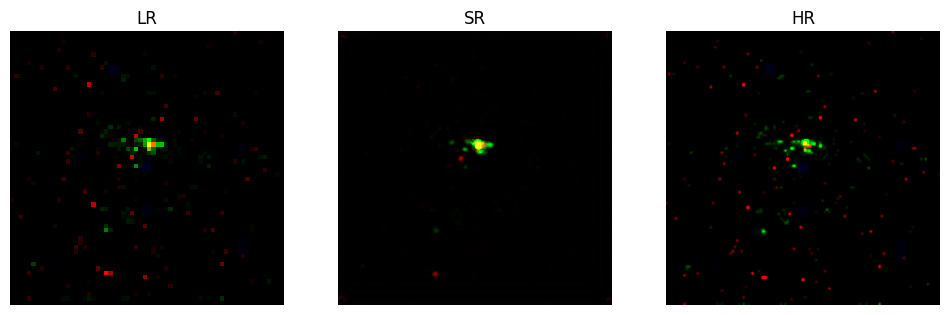

Epoch [171/200] Loss D: 0.000000 Loss G: 0.053413
Epoch [172/200] Loss D: 0.000000 Loss G: 0.075502
Epoch [173/200] Loss D: 0.000000 Loss G: 0.047460
Epoch [174/200] Loss D: 0.000000 Loss G: 0.057082
Epoch [175/200] Loss D: 0.000000 Loss G: 0.067674
Epoch [176/200] Loss D: 0.000000 Loss G: 0.053766
Epoch [177/200] Loss D: 0.000000 Loss G: 0.052577
Epoch [178/200] Loss D: 0.000000 Loss G: 0.085673
Epoch [179/200] Loss D: 0.000000 Loss G: 0.095315
Epoch [180/200] Loss D: 0.000000 Loss G: 0.072766


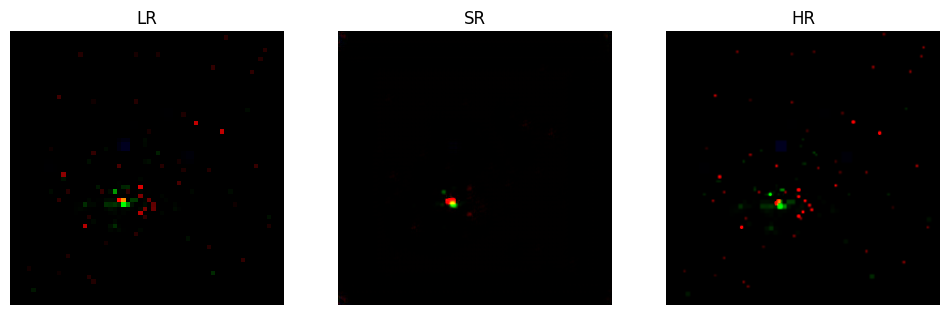

Epoch [181/200] Loss D: 0.000000 Loss G: 0.053766
Epoch [182/200] Loss D: 0.000000 Loss G: 0.078495
Epoch [183/200] Loss D: 0.000000 Loss G: 0.062884
Epoch [184/200] Loss D: 0.000000 Loss G: 0.070718
Epoch [185/200] Loss D: 0.000000 Loss G: 0.061126
Epoch [186/200] Loss D: 0.000000 Loss G: 0.059348
Epoch [187/200] Loss D: 0.000000 Loss G: 0.062349
Epoch [188/200] Loss D: 0.000000 Loss G: 0.055171
Epoch [189/200] Loss D: 0.000000 Loss G: 0.056431
Epoch [190/200] Loss D: 0.000000 Loss G: 0.053771


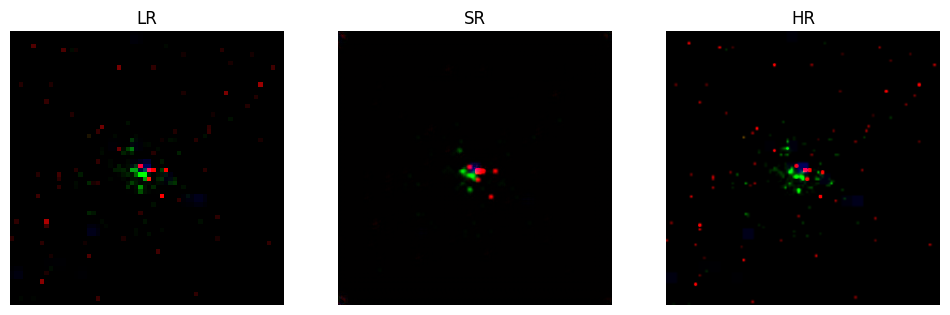

Epoch [191/200] Loss D: 0.000000 Loss G: 0.056596
Epoch [192/200] Loss D: 0.000000 Loss G: 0.054743
Epoch [193/200] Loss D: 0.000000 Loss G: 0.052868
Epoch [194/200] Loss D: 0.000000 Loss G: 0.058057
Epoch [195/200] Loss D: 0.000000 Loss G: 0.059273
Epoch [196/200] Loss D: 0.000000 Loss G: 0.051390
Epoch [197/200] Loss D: 0.000000 Loss G: 0.075253
Epoch [198/200] Loss D: 0.000000 Loss G: 0.060159
Epoch [199/200] Loss D: 0.000000 Loss G: 0.048366
Epoch [200/200] Loss D: 0.000000 Loss G: 0.052433


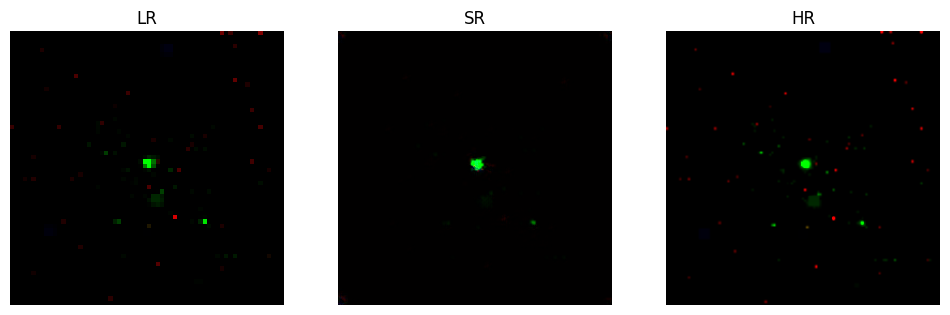

In [146]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

num_epochs = 200

for epoch in range(1, num_epochs+1):
    for lr_batch, hr_batch, _ in dataloader:
        lr_batch = lr_batch.to(device)
        hr_batch = hr_batch.to(device)

        # Train Discriminator
        optimizer_D.zero_grad()
        sr_batch_detach = G(lr_batch).detach()  # detach for D
        real_labels = torch.ones_like(D(hr_batch))
        fake_labels = torch.zeros_like(D(sr_batch_detach))
        loss_D = adversarial_loss_fn(D(hr_batch), real_labels) + adversarial_loss_fn(D(sr_batch_detach), fake_labels)
        loss_D.backward()
        optimizer_D.step()

       
        # Train Generator
      
        optimizer_G.zero_grad()
        sr_batch = G(lr_batch)
        
        # Fix: resize HR to match SR
        hr_resized = F.interpolate(hr_batch, size=sr_batch.shape[2:], mode='bilinear', align_corners=False)
        
        loss_content = content_loss_fn(sr_batch, hr_resized)
        loss_adv = adversarial_loss_fn(D(sr_batch), torch.ones_like(D(sr_batch)))
        loss_G = loss_content + 1e-3 * loss_adv
        loss_G.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch}/{num_epochs}] Loss D: {loss_D.item():.6f} Loss G: {loss_G.item():.6f}")

    # Visualization every 10 epochs
   
    if epoch % 10 == 0:
        with torch.no_grad():
            sample_lr, sample_hr, _ = next(iter(dataloader))
            sample_lr = sample_lr.to(device)
            sample_hr = sample_hr.to(device)

            sr_sample = G(sample_lr)
            # Resize HR for proper comparison
            sample_hr_resized = F.interpolate(sample_hr, size=sr_sample.shape[2:], mode='bilinear', align_corners=False)

            # Prepare images for display
            def to_display(x):
                x = (x.permute(0,2,3,1).cpu().detach().numpy() + 1) / 2  # [-1,1] -> [0,1]
                x = x.clip(0,1)
                return x

            lr_disp = to_display(sample_lr)
            sr_disp = to_display(sr_sample)
            hr_disp = to_display(sample_hr_resized)

            # Show first image in batch
            plt.figure(figsize=(12,4))
            plt.subplot(1,3,1)
            plt.title("LR")
            plt.imshow(lr_disp[0])
            plt.axis("off")

            plt.subplot(1,3,2)
            plt.title("SR")
            plt.imshow(sr_disp[0])
            plt.axis("off")

            plt.subplot(1,3,3)
            plt.title("HR")
            plt.imshow(hr_disp[0])
            plt.axis("off")

            plt.show()